# Linear Regression - Used Cars Price Prediction

## Importing Libraries

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset

In [28]:
df = pd.read_csv('/content/uncleaned_used_cars_eda(1).csv')

## Data Inspection and Cleaning

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123 entries, 0 to 122
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   car_id           123 non-null    object 
 1   brand            116 non-null    object 
 2   model            123 non-null    object 
 3   year             123 non-null    object 
 4   price_inr        118 non-null    float64
 5   km_driven        123 non-null    object 
 6   fuel_type        123 non-null    object 
 7   transmission     120 non-null    object 
 8   owner_type       123 non-null    object 
 9   mileage_kmpl     118 non-null    float64
 10  engine_cc        119 non-null    float64
 11  city             123 non-null    object 
 12  insurance_valid  123 non-null    object 
 13  seller_rating    123 non-null    float64
 14  listed_date      123 non-null    object 
dtypes: float64(4), object(11)
memory usage: 14.5+ KB


In [30]:
df.duplicated().sum()

np.int64(3)

In [31]:
df = df.drop_duplicates()

In [32]:
df.isnull().sum()

,0
car_id,0
brand,6
model,0
year,0
price_inr,5
km_driven,0
fuel_type,0
transmission,3
owner_type,0
mileage_kmpl,5


In [33]:
df['brand'] = df['brand'].fillna('Unknown')
df['price_inr'] = df['price_inr'].fillna(df['price_inr'].median())
df['transmission'] = df['transmission'].fillna('Unknown')
df['mileage_kmpl'] = df['mileage_kmpl'].fillna(df['mileage_kmpl'].median())
df['engine_cc'] = df['engine_cc'].fillna(df['engine_cc'].median())

In [51]:
df.isnull().sum()

,0
car_id,0
brand,0
model,0
year,0
price_inr,0
km_driven,0
fuel_type,0
transmission,0
owner_type,0
mileage_kmpl,0


### Observation

The dataset contained duplicate records and missing values. Duplicate records were removed, and missing values were handled using suitable methods. The cleaned dataset was then used for building the Linear Regression model.

## Feature Selection

In [52]:
X = df[['mileage_kmpl', 'engine_cc', 'seller_rating']]
y = df['price_inr']

### Observation

Mileage, engine capacity, and seller rating were selected as the input features, while price was selected as the target variable for prediction.

## Train-Test Split

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [37]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((96, 3), (24, 3), (96,), (24,))

### Observation

The dataset was divided into 80% training data and 20% testing data. The training data was used to build the model, while the testing data was used to evaluate its performance.

## Feature Scaling

In [38]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [39]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

### Observation

StandardScaler was used to bring the input features to a similar scale before training the Linear Regression model.

## Linear Regression Model

In [40]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

### Observation

A Linear Regression model was trained using the selected car features to predict the price of used cars.

## Model Prediction

In [41]:
y_pred = model.predict(X_test)
y_pred

array([ 715247.67978249,  882887.54751011,  736247.43331469,
        896991.40959708,  829161.46586925,  729785.81050964,
        783077.62351032,  671975.39357425,  778993.28821578,
        826349.90971855, 1035555.0158704 ,  671229.04573755,
        711163.34448795,  921641.22978363,  590787.93559614,
        669163.83742355, 1101243.64317402,  579495.62965987,
        901075.74489162,  708786.05697744, 1335967.10679279,
        754435.63069619,  725701.47521511,  615437.75578269])

### Observation

The trained model was used to predict car prices for the test data.

## Model Evaluation

In [42]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

mse, mae, r2

(102018520977.62837, 259690.47124779146, -0.17303306813158081)

### Observation

The model was evaluated using Mean Squared Error (MSE), Mean Absolute Error (MAE), and R² score to measure its prediction performance.

## Actual vs Predicted Prices

In [43]:
results = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': y_pred
})

results

,Actual Price,Predicted Price
0,1194000.0,7.152477e+05
1,234000.0,8.828875e+05
2,460000.0,7.362474e+05
3,556000.0,8.969914e+05
4,375000.0,8.291615e+05
5,997000.0,7.297858e+05
6,310000.0,7.830776e+05
7,733000.0,6.719754e+05
8,1033000.0,7.789933e+05
9,771000.0,8.263499e+05


### Observation

The table compares the actual car prices from the test data with the prices predicted by the Linear Regression model.

## Model Coefficients and Intercept

In [44]:
model.coef_, model.intercept_


(array([ 99247.39747979, -14101.82882813, 103572.17394779]),
 np.float64(805875.0))

### Observation

The model coefficients show the contribution of each selected feature to the predicted car price, while the intercept represents the baseline value of the model.

## New Car Price Prediction

In [45]:
new_car = pd.DataFrame({
    'mileage_kmpl': [18],
    'engine_cc': [1200],
    'seller_rating': [4.2]
})

new_car_scaled = scaler.transform(new_car)

predicted_price = model.predict(new_car_scaled)

print("Predicted Car Price:", predicted_price[0])

Predicted Car Price: 886771.0363321984


### Observation

The trained Linear Regression model predicted an estimated price of approximately ₹8.87 lakh for the given car features.

## Actual vs Predicted Plot

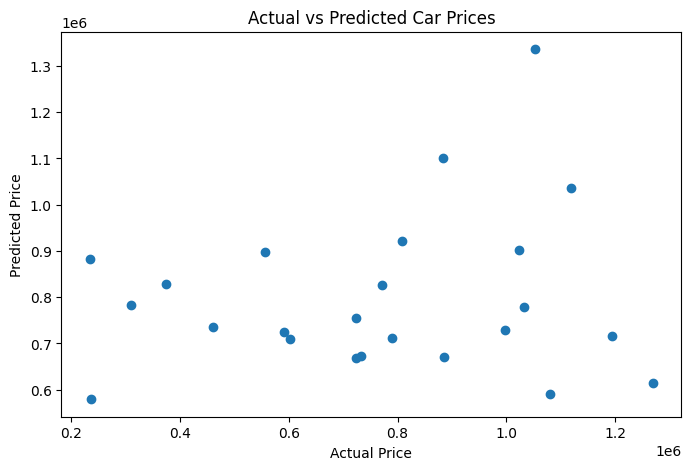

In [46]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")

plt.show()

### Observation

The plot compares actual car prices with the prices predicted by the model. The difference between the points indicates prediction errors.

## Best Fit Line

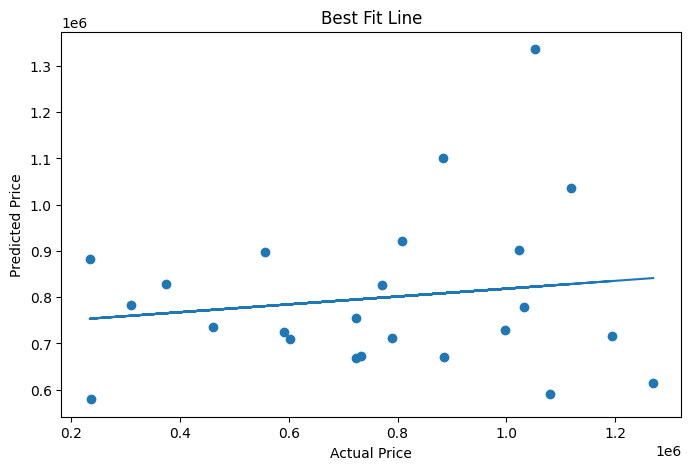

In [47]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred)

m, c = np.polyfit(y_test, y_pred, 1)

plt.plot(y_test, m * y_test + c)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Best Fit Line")

plt.show()

### Observation

The Best Fit Line represents the relationship between the actual and predicted car prices. Points closer to the line indicate predictions closer to the actual values.

## Final Model Results

In [48]:
print("Mean Squared Error (MSE):", mse)
print("Mean Absolute Error (MAE):", mae)
print("R² Score:", r2)

Mean Squared Error (MSE): 102018520977.62837
Mean Absolute Error (MAE): 259690.47124779146
R² Score: -0.17303306813158081


### Observation

The final MSE, MAE, and R² values summarize the performance of the Linear Regression model on the test data.

## Save Model and Predictions

In [49]:
results.to_csv('/content/linear_regression_predictions.csv', index=False)
import joblib

joblib.dump(model, '/content/car_price_linear_regression_model.pkl')

['/content/car_price_linear_regression_model.pkl']

In [50]:
print("Linear Regression project completed successfully.")
print("Model saved as: car_price_linear_regression_model.pkl")
print("Predictions saved as: linear_regression_predictions.csv")

Linear Regression project completed successfully.
Model saved as: car_price_linear_regression_model.pkl
Predictions saved as: linear_regression_predictions.csv


### Observation

The trained model and prediction results were saved successfully for future use and reference.